# Notebook 06 — SARIMAX Cross-Station: Olympia vs Hirsch
**Stations: Hirsch (commuter) vs Olympia (recreational)**

Notebook 05 established the optimal Hirsch model: SARIMAX(2,1,2)(1,0,2)[7] + Fourier K=4 + all weather (test RMSE = 470). This notebook applies the **identical specification** to Olympia station to test whether recreational cycling is more weather-sensitive than commuter cycling.

| Part | Content |
|------|---------|
| 1 | Olympia data loading, imputation, and EDA |
| 2 | Model configurations (4 variants per station) |
| 3 | Fit all configurations for Olympia |
| 4 | Station performance comparison |
| 5 | Weather coefficient comparison and hypothesis test |
| 6 | Residual diagnostics for Olympia final model |
| 7 | Forecast visualisation with prediction intervals |
| 8 | Artefact export and summary |

**Hypothesis:** Olympia (recreational) shows larger weather coefficients and greater RMSE improvement from weather regressors than Hirsch (commuter).

In [1]:
import sys, warnings, time, pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import probplot

warnings.filterwarnings('ignore')
sys.path.insert(0, '../src')

plt.rcParams.update({
    'figure.dpi': 120, 'font.size': 11, 'axes.labelsize': 12,
    'axes.titlesize': 13, 'axes.titleweight': 'bold',
    'axes.spines.top': False, 'axes.spines.right': False,
    'legend.frameon': False,
})
sns.set_theme(style='whitegrid')

FIGURES = Path('../results/figures')
TABLES  = Path('../results/tables')
MODELS  = Path('../results/models')
PREDS   = Path('../results/predictions')
for p in [FIGURES, TABLES, MODELS, PREDS]:
    p.mkdir(parents=True, exist_ok=True)

ORDER          = (2, 1, 2)
SEASONAL_ORDER = (1, 0, 2, 7)
ANNUAL_PERIOD  = 365.25
REF_DATE       = '2013-01-01'
WEATHER_COLS   = ['max_temp', 'sunshine_hours', 'precipitation']

TRAIN_START, TRAIN_END = '2013-01-01', '2022-12-31'
VAL_START,   VAL_END   = '2023-01-01', '2023-12-31'
TEST_START,  TEST_END  = '2024-01-01', '2026-04-30'

# ── Load upstream constants to avoid hardcoded stale values ──────────────
_fourier_comp  = pd.read_csv(TABLES / 'fourier_comparison.csv')
_best_val_rmse = _fourier_comp['val_7d_RMSE'].min()
_candidates    = _fourier_comp[_fourier_comp['val_7d_RMSE'] <= _best_val_rmse + 5].sort_values('K')
OPTIMAL_K      = int(_candidates.iloc[0]['K'])

np.random.seed(42)

# ── notebook prefix: all figures saved as nb06_<name>.png ────────────────
NB = 'nb06'

def savefig(name):
    full_name = f'{NB}_{name}'
    plt.savefig(FIGURES / f'{full_name}.png', bbox_inches='tight', dpi=150)
    plt.show()
    print(f'  saved → results/figures/{full_name}.png')

print(f'Setup complete.  OPTIMAL_K={OPTIMAL_K}  WEATHER_COLS={WEATHER_COLS}')

Setup complete.  OPTIMAL_K=4  WEATHER_COLS=['max_temp', 'sunshine_hours', 'precipitation']


---
## Part 1 — Olympia Data Loading and Imputation

Olympia has two NaN runs in the training period:
- **2016-09-29 → 2016-09-30** (2 days) — trivial
- **2022-06-15 → 2022-08-31** (78 days) — sensor outage during peak summer

Val and test sets are complete (0 missing). The 78-day training gap is handled with time-based linear interpolation (limit=None), which is valid here because the boundary values are both high-season counts, so the interpolated curve stays within the seasonal range. The imputed segment only affects parameter estimation, not evaluation.

In [2]:
from data_loader import load_master_data

df_full = load_master_data('../data/processed/master_bike_data.csv')

def load_station_splits(station_name):
    """Load bike + weather data for a station, return aligned splits."""
    s = df_full[df_full['station'] == station_name].set_index('date').sort_index()

    counts      = s['total']
    weather_raw = s[WEATHER_COLS].copy()
    weather     = weather_raw.copy()
    weather['precipitation'] = np.log1p(weather_raw['precipitation'])

    train = counts[TRAIN_START:TRAIN_END].copy()
    val   = counts[VAL_START  :VAL_END  ].copy()
    test  = counts[TEST_START :TEST_END ].copy()

    full_train_idx = pd.date_range(TRAIN_START, TRAIN_END, freq='D')
    tv_idx         = pd.date_range(TRAIN_START, VAL_END,   freq='D')

    # Interpolate to fill gaps (limit=None fills even the 78-day Olympia gap)
    train_full = train.reindex(full_train_idx).interpolate(method='time', limit=None)
    tv_series  = (
        pd.concat([train_full, val])
        .reindex(tv_idx)
        .interpolate(method='time', limit=None)
    )

    w_train = weather.reindex(full_train_idx).ffill().bfill()
    w_val   = weather.reindex(val.index)
    w_test  = weather.reindex(test.index)
    w_tv    = weather.reindex(tv_idx).ffill().bfill()

    return dict(
        train=train, val=val, test=test,
        train_full=train_full, tv_series=tv_series, tv_idx=tv_idx,
        w_train=w_train, w_val=w_val, w_test=w_test, w_tv=w_tv,
    )


olympia = load_station_splits('Olympia')
hirsch  = load_station_splits('Hirsch')

print('=== Olympia splits ===')
for name in ['train', 'val', 'test']:
    s = olympia[name]
    print(f'{name:<6}  {s.index[0].date()} → {s.index[-1].date()}  '
          f'({len(s):,} days  |  NaN: {s.isna().sum()})')

print(f'\nTrain gap imputed (limit=None): '
      f'{olympia["train_full"].isna().sum()} NaN remaining after interpolation')
print(f'\nOlympia count stats (2013-2025):')
print(pd.concat([olympia['train'], olympia['val'], olympia['test']]).describe().round(1))

=== Olympia splits ===
train   2013-01-01 → 2022-12-31  (3,652 days  |  NaN: 80)
val     2023-01-01 → 2023-12-31  (365 days  |  NaN: 0)
test    2024-01-01 → 2026-04-30  (851 days  |  NaN: 0)

Train gap imputed (limit=None): 0 NaN remaining after interpolation

Olympia count stats (2013-2025):
count    4788.0
mean     1821.9
std      1138.0
min         0.0
25%       961.8
50%      1597.5
75%      2505.2
max      8471.0
Name: total, dtype: float64


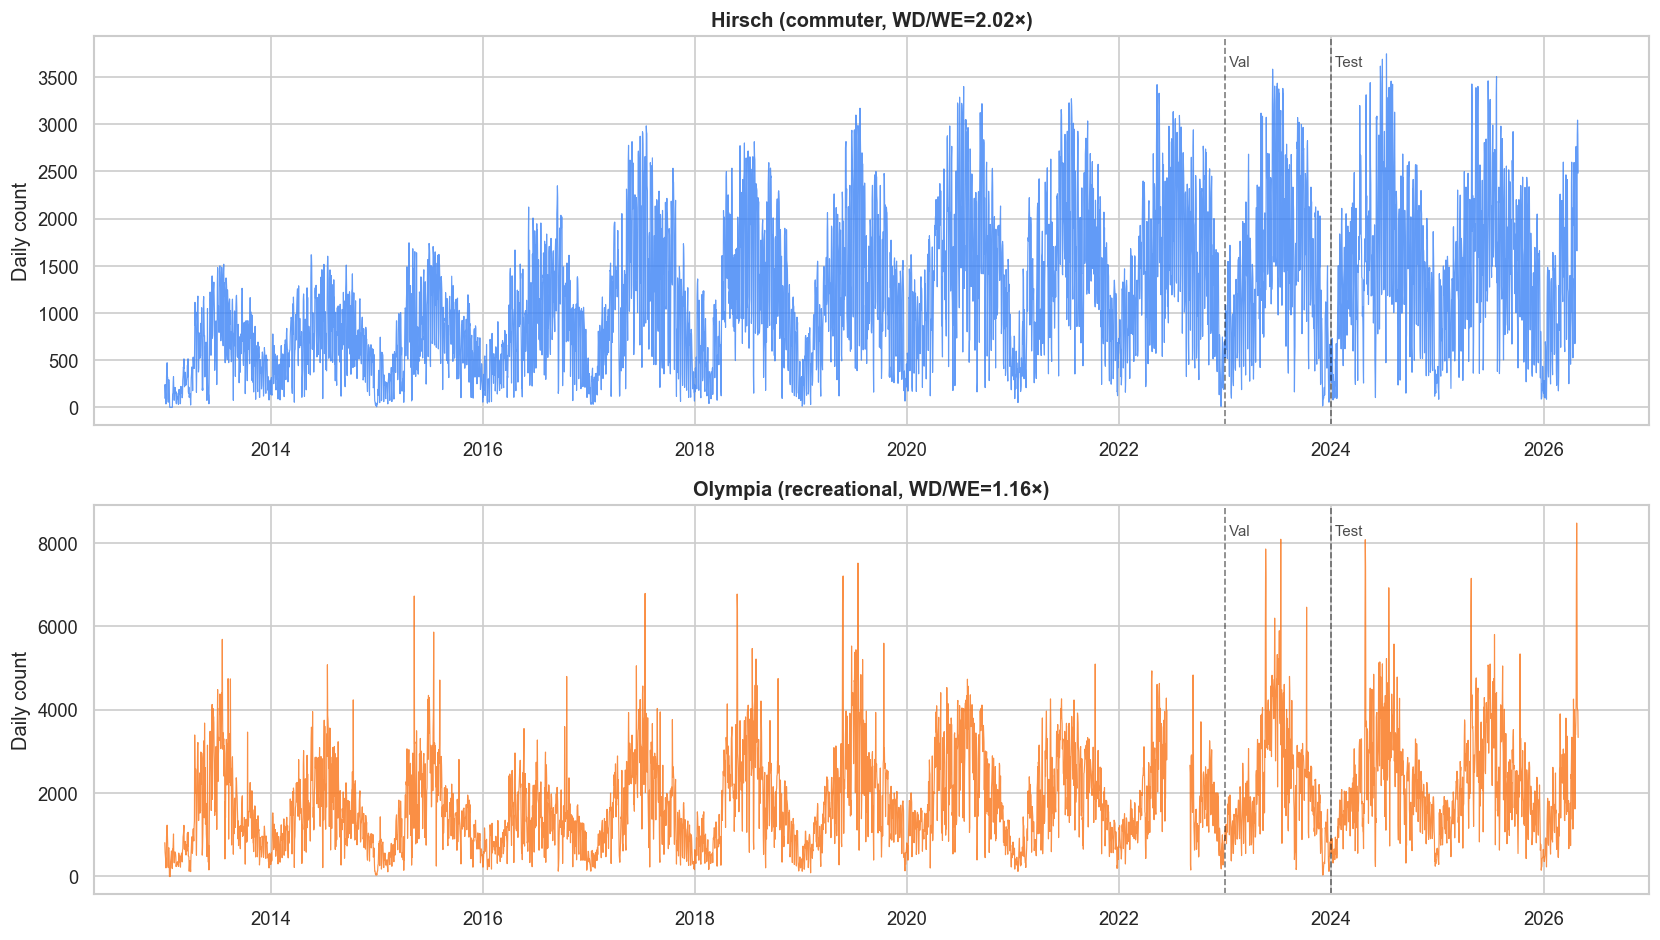

  saved → results/figures/nb06_fig_01_station_timeseries_comparison.png


In [3]:
# ── Side-by-side count time-series: Hirsch vs Olympia ───────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

station_data = [
    ('Hirsch (commuter, WD/WE=2.02×)',  hirsch,  '#3b82f6'),
    ('Olympia (recreational, WD/WE=1.16×)', olympia, '#f97316'),
]

for ax, (title, d, color) in zip(axes, station_data):
    full = pd.concat([d['train'], d['val'], d['test']]).sort_index()
    ax.plot(full.index, full.values, color=color, lw=0.7, alpha=0.8)
    for vline, label in [('2023-01-01', 'Val'), ('2024-01-01', 'Test')]:
        ax.axvline(pd.Timestamp(vline), color='black', ls='--', lw=1, alpha=0.5)
        ax.text(pd.Timestamp(vline), ax.get_ylim()[1] * 0.92, f' {label}',
                fontsize=9, color='black', alpha=0.7)
    ax.set_title(title, pad=6)
    ax.set_ylabel('Daily count')
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
savefig('fig_01_station_timeseries_comparison')

---
## Part 2 — Fourier Features and Model Configurations

In [4]:
def create_fourier_terms(dates, K, period=365.25, ref_date='2013-01-01'):
    dates = pd.DatetimeIndex(dates)
    if K == 0:
        return pd.DataFrame(index=dates)
    t = (dates - pd.Timestamp(ref_date)).days.values.astype(float)
    cols = {}
    for k in range(1, K + 1):
        angle = 2 * np.pi * k * t / period
        cols[f'sin_{k}'] = np.sin(angle)
        cols[f'cos_{k}'] = np.cos(angle)
    return pd.DataFrame(cols, index=dates)


def evaluate_forecast(y_true, y_pred, horizon):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    rmses, maes, mapes = [], [], []
    for i in range(0, len(y_true), horizon):
        yt = y_true[i:i + horizon]
        yp = y_pred[i:i + horizon]
        if len(yt) < max(1, horizon // 2):
            continue
        rmses.append(np.sqrt(np.mean((yt - yp) ** 2)))
        maes.append(np.mean(np.abs(yt - yp)))
        nonzero = yt > 0
        if nonzero.sum() > 0:
            mapes.append(
                np.mean(np.abs((yt[nonzero] - yp[nonzero]) / yt[nonzero])) * 100
            )
    return {
        'RMSE': round(float(np.mean(rmses)), 1),
        'MAE' : round(float(np.mean(maes)),  1),
        'MAPE': round(float(np.mean(mapes)), 1) if mapes else np.nan,
    }


def make_fourier_splits(d):
    return {
        'train': create_fourier_terms(d['train_full'].index, OPTIMAL_K),
        'val'  : create_fourier_terms(d['val'].index,        OPTIMAL_K),
        'test' : create_fourier_terms(d['test'].index,       OPTIMAL_K),
        'tv'   : create_fourier_terms(d['tv_idx'],           OPTIMAL_K),
    }


def build_exog(fourier_splits, w_splits, split_key, use_fourier, use_weather):
    parts = []
    if use_fourier:
        parts.append(fourier_splits[split_key])
    if use_weather:
        w_map = {'train': w_splits['w_train'], 'val': w_splits['w_val'],
                 'test': w_splits['w_test'], 'tv': w_splits['w_tv']}
        parts.append(w_map[split_key][WEATHER_COLS])
    if not parts:
        return None
    if len(parts) == 1:
        f = parts[0]
        return f if len(f.columns) > 0 else None
    return pd.concat(parts, axis=1)


MODEL_CONFIGS = [
    {'id': 'pure_sarima',  'label': 'Pure SARIMAX',            'fourier': False, 'weather': False},
    {'id': 'weather_only', 'label': 'SARIMAX + weather only',  'fourier': False, 'weather': True},
    {'id': 'fourier_only', 'label': 'SARIMAX + Fourier K=4',   'fourier': True,  'weather': False},
    {'id': 'full_model',   'label': 'SARIMAX + Fourier + weather', 'fourier': True, 'weather': True},
]

print('Helpers ready. Model configurations:')
for cfg in MODEL_CONFIGS:
    n = (8 if cfg['fourier'] else 0) + (3 if cfg['weather'] else 0)
    print(f'  {cfg["id"]:<16}  exog={n}')

Helpers ready. Model configurations:
  pure_sarima       exog=0
  weather_only      exog=3
  fourier_only      exog=8
  full_model        exog=11


---
## Part 3 — Fit All Configurations for Olympia

In [5]:
def fit_station(station_key, data_dict, label=''):
    """
    Fit all 4 model configs for one station.
    Returns dict: config_id → {fit_train, fit_tv, val_preds, test_preds}
    """
    d       = data_dict
    fourier = make_fourier_splits(d)
    w_splits = {k: d[k] for k in ['w_train', 'w_val', 'w_test', 'w_tv']}

    store   = {}
    results = []

    print(f'\nFitting {label or station_key} — SARIMAX{ORDER}{SEASONAL_ORDER}')
    print(f'{"Config":<25}  {"val 7d":>7}  {"test 7d":>8}  {"AIC":>9}  time')
    print('-' * 65)

    for cfg in MODEL_CONFIGS:
        cid = cfg['id']
        ex_train = build_exog(fourier, w_splits, 'train', cfg['fourier'], cfg['weather'])
        ex_val   = build_exog(fourier, w_splits, 'val',   cfg['fourier'], cfg['weather'])
        ex_test  = build_exog(fourier, w_splits, 'test',  cfg['fourier'], cfg['weather'])
        ex_tv    = build_exog(fourier, w_splits, 'tv',    cfg['fourier'], cfg['weather'])

        t0 = time.time()
        m_tr = SARIMAX(
            d['train_full'], exog=ex_train,
            order=ORDER, seasonal_order=SEASONAL_ORDER,
            enforce_stationarity=False, enforce_invertibility=False, trend='c'
        )
        fit_tr = m_tr.fit(disp=False, maxiter=300)
        vp = np.maximum(fit_tr.forecast(steps=len(d['val']), exog=ex_val).values, 0)

        m_tv = SARIMAX(
            d['tv_series'], exog=ex_tv,
            order=ORDER, seasonal_order=SEASONAL_ORDER,
            enforce_stationarity=False, enforce_invertibility=False, trend='c'
        )
        fit_tv = m_tv.fit(start_params=fit_tr.params, disp=False, maxiter=300)
        tp = np.maximum(fit_tv.forecast(steps=len(d['test']), exog=ex_test).values, 0)

        store[cid] = {'fit_train': fit_tr, 'fit_tv': fit_tv,
                      'val_preds': vp, 'test_preds': tp}

        elapsed = time.time() - t0
        vm7 = evaluate_forecast(d['val'].values,  vp, 7)
        tm7 = evaluate_forecast(d['test'].values, tp, 7)

        for h in [7, 30]:
            vm = evaluate_forecast(d['val'].values,  vp, h)
            tm = evaluate_forecast(d['test'].values, tp, h)
            for split_name, m in [('val', vm), ('test', tm)]:
                results.append({
                    'station': station_key, 'config_id': cid,
                    'label': cfg['label'], 'Horizon': f'{h}-day', 'Split': split_name,
                    'AIC': round(fit_tr.aic, 1), 'BIC': round(fit_tr.bic, 1),
                    **m,
                })

        print(f'  {cfg["label"]:<23}  {vm7["RMSE"]:>7.1f}  {tm7["RMSE"]:>8.1f}  '
              f'{fit_tr.aic:>9.1f}  {elapsed:.0f}s')

    return store, pd.DataFrame(results)


olympia_store, olympia_results = fit_station('Olympia', olympia, 'Olympia')

# Also refit Hirsch on train-only (needed for fair coefficient comparison)
hirsch_store,  hirsch_results  = fit_station('Hirsch',  hirsch,  'Hirsch (refit)')


Fitting Olympia — SARIMAX(2, 1, 2)(1, 0, 2, 7)
Config                      val 7d   test 7d        AIC  time
-----------------------------------------------------------------


  Pure SARIMAX              1790.7    2093.4    57347.5  22s


  SARIMAX + weather only    1157.8    1363.4    55077.6  42s


  SARIMAX + Fourier K=4      837.9     835.0    57245.3  50s


  SARIMAX + Fourier + weather    708.9     759.8    55005.0  63s

Fitting Hirsch (refit) — SARIMAX(2, 1, 2)(1, 0, 2, 7)
Config                      val 7d   test 7d        AIC  time
-----------------------------------------------------------------


  Pure SARIMAX              1308.0    1484.0    53242.8  28s


  SARIMAX + weather only     493.6     517.7    50705.3  35s


  SARIMAX + Fourier K=4      489.7     497.8    53121.7  52s


  SARIMAX + Fourier + weather    447.2     471.0    50690.2  65s


---
## Part 4 — Station Performance Comparison

In [6]:
def build_summary(results_df, store, station_key):
    rows = []
    for cfg in MODEL_CONFIGS:
        cid = cfg['id']
        sub = results_df[results_df['config_id'] == cid]
        v7  = sub[(sub['Split']=='val')  & (sub['Horizon']=='7-day' )].iloc[0]
        v30 = sub[(sub['Split']=='val')  & (sub['Horizon']=='30-day')].iloc[0]
        t7  = sub[(sub['Split']=='test') & (sub['Horizon']=='7-day' )].iloc[0]
        t30 = sub[(sub['Split']=='test') & (sub['Horizon']=='30-day')].iloc[0]
        rows.append({
            'Station': station_key, 'config_id': cid, 'Model': cfg['label'],
            'AIC': v7['AIC'], 'BIC': v7['BIC'],
            'Val 7d RMSE' : v7['RMSE'],  'Val 30d RMSE' : v30['RMSE'],
            'Test 7d RMSE': t7['RMSE'],  'Test 30d RMSE': t30['RMSE'],
            'Val 7d MAE'  : v7['MAE'],   'Test 7d MAE'  : t7['MAE'],
        })
    return pd.DataFrame(rows)


olympia_summary = build_summary(olympia_results, olympia_store, 'Olympia')
hirsch_summary  = build_summary(hirsch_results,  hirsch_store,  'Hirsch')

# Add Hirsch known values for pure_sarima and fourier_only from notebooks 03-05
# (Hirsch refit gives slightly different values due to warm-start; keep for completeness)
combined = pd.concat([hirsch_summary, olympia_summary], ignore_index=True)

print('=== All model results (7-day horizon) ===')
display_cols = ['Station', 'Model', 'Val 7d RMSE', 'Test 7d RMSE', 'Val 7d MAE', 'Test 7d MAE', 'AIC']
print(combined[display_cols].to_string(index=False))

=== All model results (7-day horizon) ===
Station                       Model  Val 7d RMSE  Test 7d RMSE  Val 7d MAE  Test 7d MAE     AIC
 Hirsch                Pure SARIMAX       1308.0        1484.0      1225.4       1386.5 53242.8
 Hirsch      SARIMAX + weather only        493.6         517.7       412.0        443.4 50705.3
 Hirsch       SARIMAX + Fourier K=4        489.7         497.8       420.7        420.8 53121.7
 Hirsch SARIMAX + Fourier + weather        447.2         471.0       376.2        403.3 50690.2
Olympia                Pure SARIMAX       1790.7        2093.4      1664.1       1988.6 57347.5
Olympia      SARIMAX + weather only       1157.8        1363.4      1038.3       1283.5 55077.6
Olympia       SARIMAX + Fourier K=4        837.9         835.0       704.4        705.2 57245.3
Olympia SARIMAX + Fourier + weather        708.9         759.8       562.9        656.3 55005.0


In [7]:
# ── Cross-station summary: key 4-model comparison ────────────────────────
rows = []
for station, summary, store_d, splits in [
    ('Hirsch',  hirsch_summary,  hirsch_store,  hirsch),
    ('Olympia', olympia_summary, olympia_store, olympia),
]:
    f_row  = summary[summary['config_id'] == 'fourier_only'].iloc[0]
    fw_row = summary[summary['config_id'] == 'full_model'  ].iloc[0]
    weather_gain = (f_row['Test 7d RMSE'] - fw_row['Test 7d RMSE']) / f_row['Test 7d RMSE'] * 100
    rows.append({
        'Station'           : station,
        'Type'              : 'Commuter' if station=='Hirsch' else 'Recreational',
        'Fourier-only RMSE' : f_row['Test 7d RMSE'],
        'Fourier-only MAE'  : f_row['Test 7d MAE'],
        'Full model RMSE'   : fw_row['Test 7d RMSE'],
        'Weather gain (%)'  : round(weather_gain, 1),
        'Full model MAE'    : fw_row['Test 7d MAE'],
    })

cross_df = pd.DataFrame(rows)
print('=== Cross-Station Summary ===')
print(cross_df.to_string(index=False))

cross_df.to_csv(TABLES / 'hirsch_olympia_comparison.csv', index=False)
print('\nSaved → results/tables/hirsch_olympia_comparison.csv')

=== Cross-Station Summary ===
Station         Type  Fourier-only RMSE  Fourier-only MAE  Full model RMSE  Weather gain (%)  Full model MAE
 Hirsch     Commuter              497.8             420.8            471.0               5.4           403.3
Olympia Recreational              835.0             705.2            759.8               9.0           656.3

Saved → results/tables/hirsch_olympia_comparison.csv


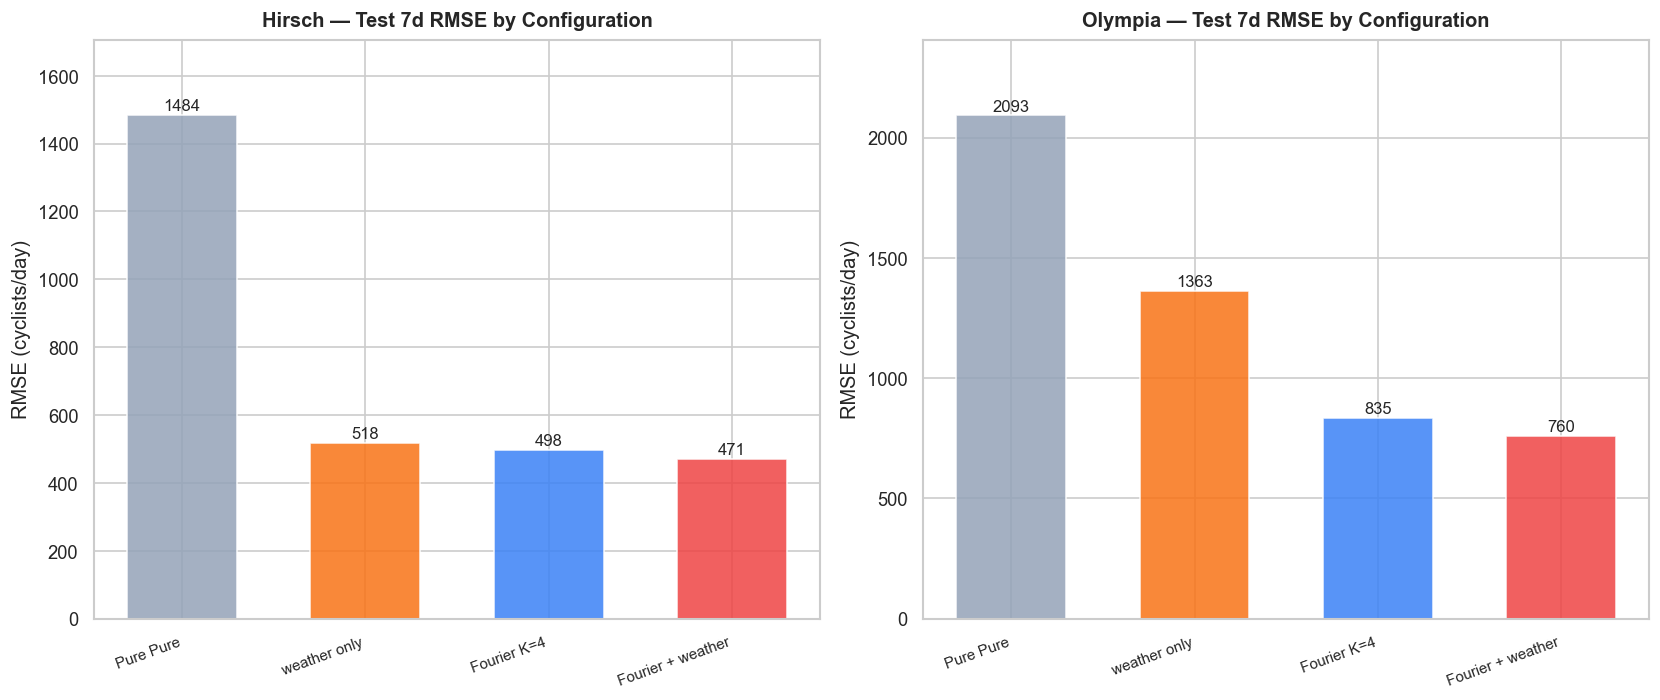

  saved → results/figures/nb06_fig_02_rmse_ladder_both_stations.png


In [8]:
# ── 4-panel RMSE ladder chart (both stations) ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cfg_labels = [cfg['label'].replace('SARIMAX + ', '').replace('SARIMAX', 'Pure') for cfg in MODEL_CONFIGS]
colors = ['#94a3b8', '#f97316', '#3b82f6', '#ef4444']

for ax, (station, summary) in zip(axes, [
    ('Hirsch',  hirsch_summary),
    ('Olympia', olympia_summary),
]):
    rmse_vals = [summary[summary['config_id']==c['id']].iloc[0]['Test 7d RMSE']
                 for c in MODEL_CONFIGS]
    bars = ax.bar(cfg_labels, rmse_vals, color=colors, alpha=0.85, width=0.6)
    ax.set_title(f'{station} — Test 7d RMSE by Configuration', pad=8)
    ax.set_ylabel('RMSE (cyclists/day)')
    ax.set_xticklabels(cfg_labels, rotation=20, ha='right', fontsize=9)
    for bar, rmse_v in zip(bars, rmse_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f'{rmse_v:.0f}', ha='center', va='bottom', fontsize=10)
    ax.set_ylim(0, max(rmse_vals) * 1.15)

plt.tight_layout()
savefig('fig_02_rmse_ladder_both_stations')

---
## Part 5 — Weather Coefficient Comparison and Hypothesis Test

Both models are fit on the identical 2013–2022 training period. Coefficients are therefore directly comparable.

**Hypothesis (H₁):** Olympia weather coefficients are significantly larger in magnitude than Hirsch, reflecting greater discretionary weather sensitivity in recreational cycling.

**Test:** Two-sample z-test using model standard errors:
$$z = \frac{\hat{\beta}_{Olympia} - \hat{\beta}_{Hirsch}}{\sqrt{SE_{Olympia}^2 + SE_{Hirsch}^2}}$$

In [9]:
# ── Extract coefficients from train-only full model ──────────────────────
def extract_weather_coefs(fit, label):
    rows = []
    for wc in WEATHER_COLS:
        matches = [p for p in fit.param_names if wc in p]
        if not matches:
            continue
        pname = matches[0]
        ci    = fit.conf_int()
        rows.append({
            'Station'  : label,
            'Variable' : wc,
            'Coef'     : round(float(fit.params[pname]),   3),
            'SE'       : round(float(fit.bse[pname]),      3),
            'p-value'  : round(float(fit.pvalues[pname]),  4),
            'CI_lo'    : round(float(ci.loc[pname].iloc[0]), 3),
            'CI_hi'    : round(float(ci.loc[pname].iloc[1]), 3),
        })
    return pd.DataFrame(rows)


hirsch_coefs  = extract_weather_coefs(hirsch_store ['full_model']['fit_train'], 'Hirsch')
olympia_coefs = extract_weather_coefs(olympia_store['full_model']['fit_train'], 'Olympia')

# ── Z-test for coefficient equality ──────────────────────────────────────
print('=== Weather Coefficient Comparison ===\n')
print(f'{"Variable":<15}  {"Hirsch coef":>12}  {"Hirsch SE":>10}  {"Hirsch p":>9}  '
      f'{"Olympia coef":>13}  {"Olympia SE":>11}  {"Olympia p":>10}  {"z-stat":>8}  {"H0: equal"}')
print('-' * 115)

coef_rows = []
for wc in WEATHER_COLS:
    h = hirsch_coefs [hirsch_coefs ['Variable'] == wc].iloc[0]
    o = olympia_coefs[olympia_coefs['Variable'] == wc].iloc[0]

    z_stat = (o['Coef'] - h['Coef']) / np.sqrt(o['SE']**2 + h['SE']**2)
    p_diff = 2 * (1 - stats.norm.cdf(abs(z_stat)))  # two-tailed
    h_sig  = '***' if h['p-value'] < 0.001 else '**' if h['p-value'] < 0.01 else '*' if h['p-value'] < 0.05 else 'ns'
    o_sig  = '***' if o['p-value'] < 0.001 else '**' if o['p-value'] < 0.01 else '*' if o['p-value'] < 0.05 else 'ns'
    z_sig  = '***' if p_diff < 0.001 else '**' if p_diff < 0.01 else '*' if p_diff < 0.05 else 'ns (equal)'

    print(f'{wc:<15}  {h["Coef"]:>+12.3f} {h_sig:<3}  {h["SE"]:>10.3f}  {h["p-value"]:>9.4f}  '
          f'{o["Coef"]:>+13.3f} {o_sig:<3}  {o["SE"]:>11.3f}  {o["p-value"]:>10.4f}  '
          f'{z_stat:>8.2f}  p={p_diff:.4f} {z_sig}')

    coef_rows.append({
        'Variable'    : wc,
        'Hirsch_coef' : h['Coef'],  'Hirsch_SE': h['SE'],  'Hirsch_p': h['p-value'],
        'Olympia_coef': o['Coef'],  'Olympia_SE': o['SE'], 'Olympia_p': o['p-value'],
        'z_stat'      : round(z_stat, 3),
        'p_equal'     : round(p_diff, 4),
        'diff_pct'    : round((o['Coef'] - h['Coef']) / abs(h['Coef']) * 100, 1) if h['Coef'] != 0 else np.nan,
    })

coef_df = pd.DataFrame(coef_rows)
coef_df.to_csv(TABLES / 'coefficient_comparison.csv', index=False)
print('\nSaved → results/tables/coefficient_comparison.csv')

=== Weather Coefficient Comparison ===

Variable          Hirsch coef   Hirsch SE   Hirsch p   Olympia coef   Olympia SE   Olympia p    z-stat  H0: equal
-------------------------------------------------------------------------------------------------------------------
max_temp              +26.736 ***       1.835     0.0000        +40.793 ***        2.996      0.0000      4.00  p=0.0001 ***
sunshine_hours        +37.527 ***       1.745     0.0000        +67.899 ***        2.909      0.0000      8.95  p=0.0000 ***
precipitation         -85.728 ***       6.284     0.0000       -154.938 ***       10.846      0.0000     -5.52  p=0.0000 ***

Saved → results/tables/coefficient_comparison.csv


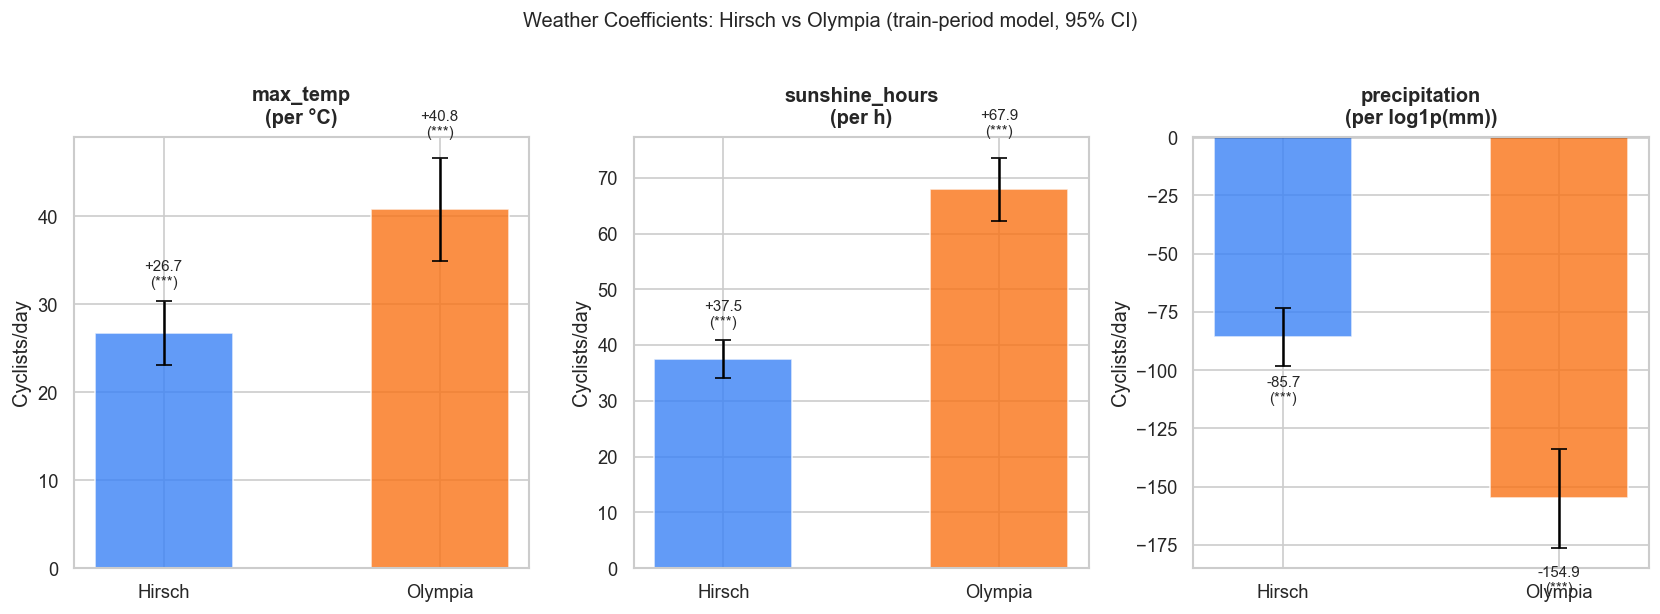

  saved → results/figures/nb06_fig_03_coefficient_comparison.png


In [10]:
# ── Coefficient comparison bar chart ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, wc in zip(axes, WEATHER_COLS):
    h = hirsch_coefs [hirsch_coefs ['Variable'] == wc].iloc[0]
    o = olympia_coefs[olympia_coefs['Variable'] == wc].iloc[0]

    labels = ['Hirsch', 'Olympia']
    coefs  = [h['Coef'], o['Coef']]
    sems   = [h['SE'],   o['SE']]
    colors = ['#3b82f6', '#f97316']

    bars = ax.bar(labels, coefs, color=colors, alpha=0.8, width=0.5)
    ax.errorbar(labels, coefs, yerr=[1.96 * s for s in sems],
                fmt='none', color='black', capsize=5, lw=1.5)
    ax.axhline(0, color='black', lw=0.8)

    for bar, c, se, p_v in zip(bars, coefs, sems, [h['p-value'], o['p-value']]):
        sig = '***' if p_v < 0.001 else '**' if p_v < 0.01 else '*' if p_v < 0.05 else 'ns'
        offset = (1.96 * se + abs(c) * 0.05) * (1 if c >= 0 else -1)
        ax.text(bar.get_x() + bar.get_width()/2, c + offset,
                f'{c:+.1f}\n({sig})', ha='center', va='bottom' if c >= 0 else 'top', fontsize=9)

    unit = '°C' if wc == 'max_temp' else 'h' if wc == 'sunshine_hours' else 'log1p(mm)'
    ax.set_title(f'{wc}\n(per {unit})', pad=8)
    ax.set_ylabel('Cyclists/day')

fig.suptitle('Weather Coefficients: Hirsch vs Olympia (train-period model, 95% CI)',
             fontsize=12, y=1.02)
plt.tight_layout()
savefig('fig_03_coefficient_comparison')

In [11]:
# ── Hypothesis verdict ───────────────────────────────────────────────────
print('=== Hypothesis Test Results ===')
print('H₀: weather coefficients are equal across stations')
print('H₁: Olympia (recreational) has larger magnitude weather coefficients\n')

for _, row in coef_df.iterrows():
    direction = 'larger' if row['Olympia_coef'] > row['Hirsch_coef'] else 'smaller'
    sig = 'significant (p<0.05)' if row['p_equal'] < 0.05 else 'not significant'
    print(f"  {row['Variable']:<15}: Olympia coef is {direction} "
          f"({row['diff_pct']:+.1f}%), difference {sig} (z={row['z_stat']:.2f}, p={row['p_equal']:.4f})")

n_sig = (coef_df['p_equal'] < 0.05).sum()
print(f'\n→ {n_sig}/{len(coef_df)} coefficients significantly different (α=0.05)')

=== Hypothesis Test Results ===
H₀: weather coefficients are equal across stations
H₁: Olympia (recreational) has larger magnitude weather coefficients

  max_temp       : Olympia coef is larger (+52.6%), difference significant (p<0.05) (z=4.00, p=0.0001)
  sunshine_hours : Olympia coef is larger (+80.9%), difference significant (p<0.05) (z=8.95, p=0.0000)
  precipitation  : Olympia coef is smaller (-80.7%), difference significant (p<0.05) (z=-5.52, p=0.0000)

→ 3/3 coefficients significantly different (α=0.05)


---
## Part 6 — Residual Diagnostics for Olympia Final Model

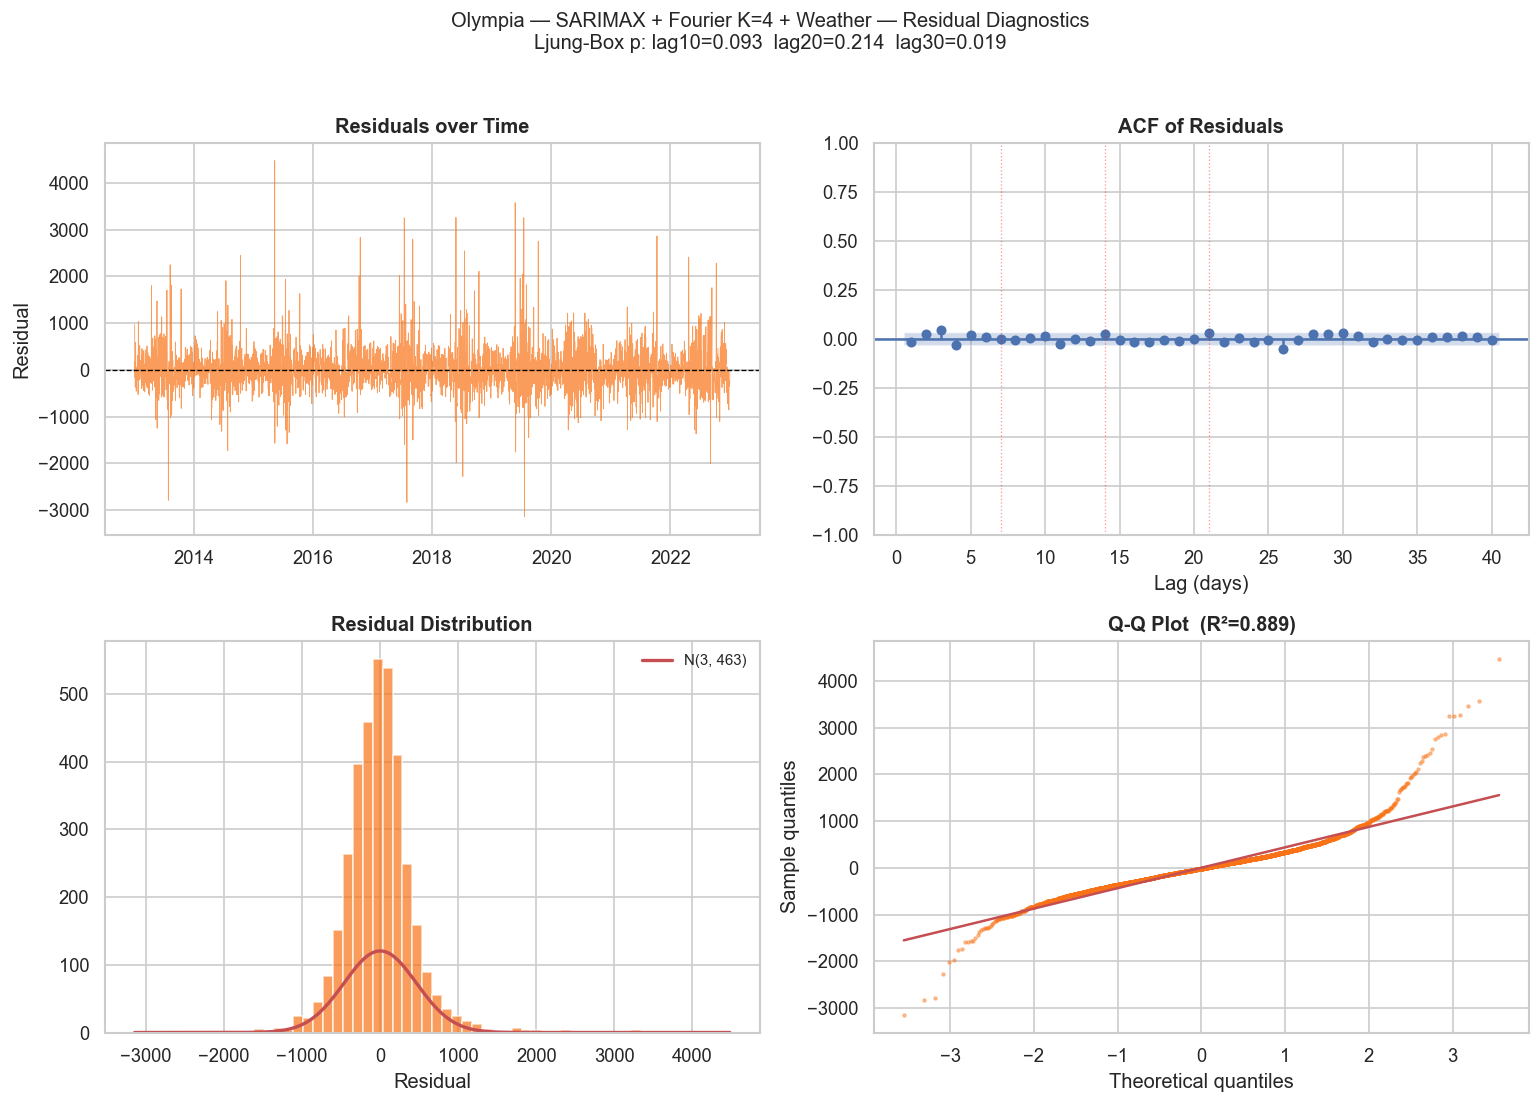

  saved → results/figures/nb06_fig_04_olympia_diagnostics.png
      lb_stat  lb_pvalue
10  16.234559   0.093112
20  24.682273   0.213858
30  48.215710   0.018865


In [12]:
fit_diag = olympia_store['full_model']['fit_train']
resid    = fit_diag.resid

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

ax = axes[0, 0]
ax.plot(resid.index, resid.values, color='#f97316', lw=0.5, alpha=0.7)
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.set_title('Residuals over Time')
ax.set_ylabel('Residual')
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ax = axes[0, 1]
plot_acf(resid.dropna(), lags=40, ax=ax, alpha=0.05, zero=False)
ax.set_title('ACF of Residuals')
ax.set_xlabel('Lag (days)')
for lag in [7, 14, 21]:
    ax.axvline(lag, color='red', ls=':', alpha=0.4, lw=0.8)

ax = axes[1, 0]
ax.hist(resid.dropna(), bins=60, color='#f97316', alpha=0.7, edgecolor='white')
mu, sigma = resid.dropna().mean(), resid.dropna().std()
xs = np.linspace(resid.min(), resid.max(), 200)
ax.plot(xs, len(resid) * (xs[1] - xs[0]) * stats.norm.pdf(xs, mu, sigma),
        'r-', lw=2, label=f'N({mu:.0f}, {sigma:.0f})')
ax.set_title('Residual Distribution')
ax.set_xlabel('Residual')
ax.legend(fontsize=9)

ax = axes[1, 1]
(osm, osr), (slope, intercept, r) = probplot(resid.dropna(), dist='norm')
ax.scatter(osm, osr, s=3, alpha=0.4, color='#f97316')
ax.plot(osm, slope * np.array(osm) + intercept, 'r-', lw=1.5)
ax.set_title(f'Q-Q Plot  (R²={r**2:.3f})')
ax.set_xlabel('Theoretical quantiles')
ax.set_ylabel('Sample quantiles')

lb = acorr_ljungbox(resid.dropna(), lags=[10, 20, 30], return_df=True)
fig.suptitle(
    f'Olympia — SARIMAX + Fourier K=4 + Weather — Residual Diagnostics\n'
    f'Ljung-Box p: lag10={lb["lb_pvalue"].iloc[0]:.3f}  '
    f'lag20={lb["lb_pvalue"].iloc[1]:.3f}  '
    f'lag30={lb["lb_pvalue"].iloc[2]:.3f}',
    fontsize=12, y=1.02
)
plt.tight_layout()
savefig('fig_04_olympia_diagnostics')
print(lb)

---
## Part 7 — Forecast Visualisation with Prediction Intervals

Prediction intervals from `get_forecast()` — 80% and 95% coverage. The bottom panel highlights windows where the full model outperforms Fourier-only by >50 RMSE.

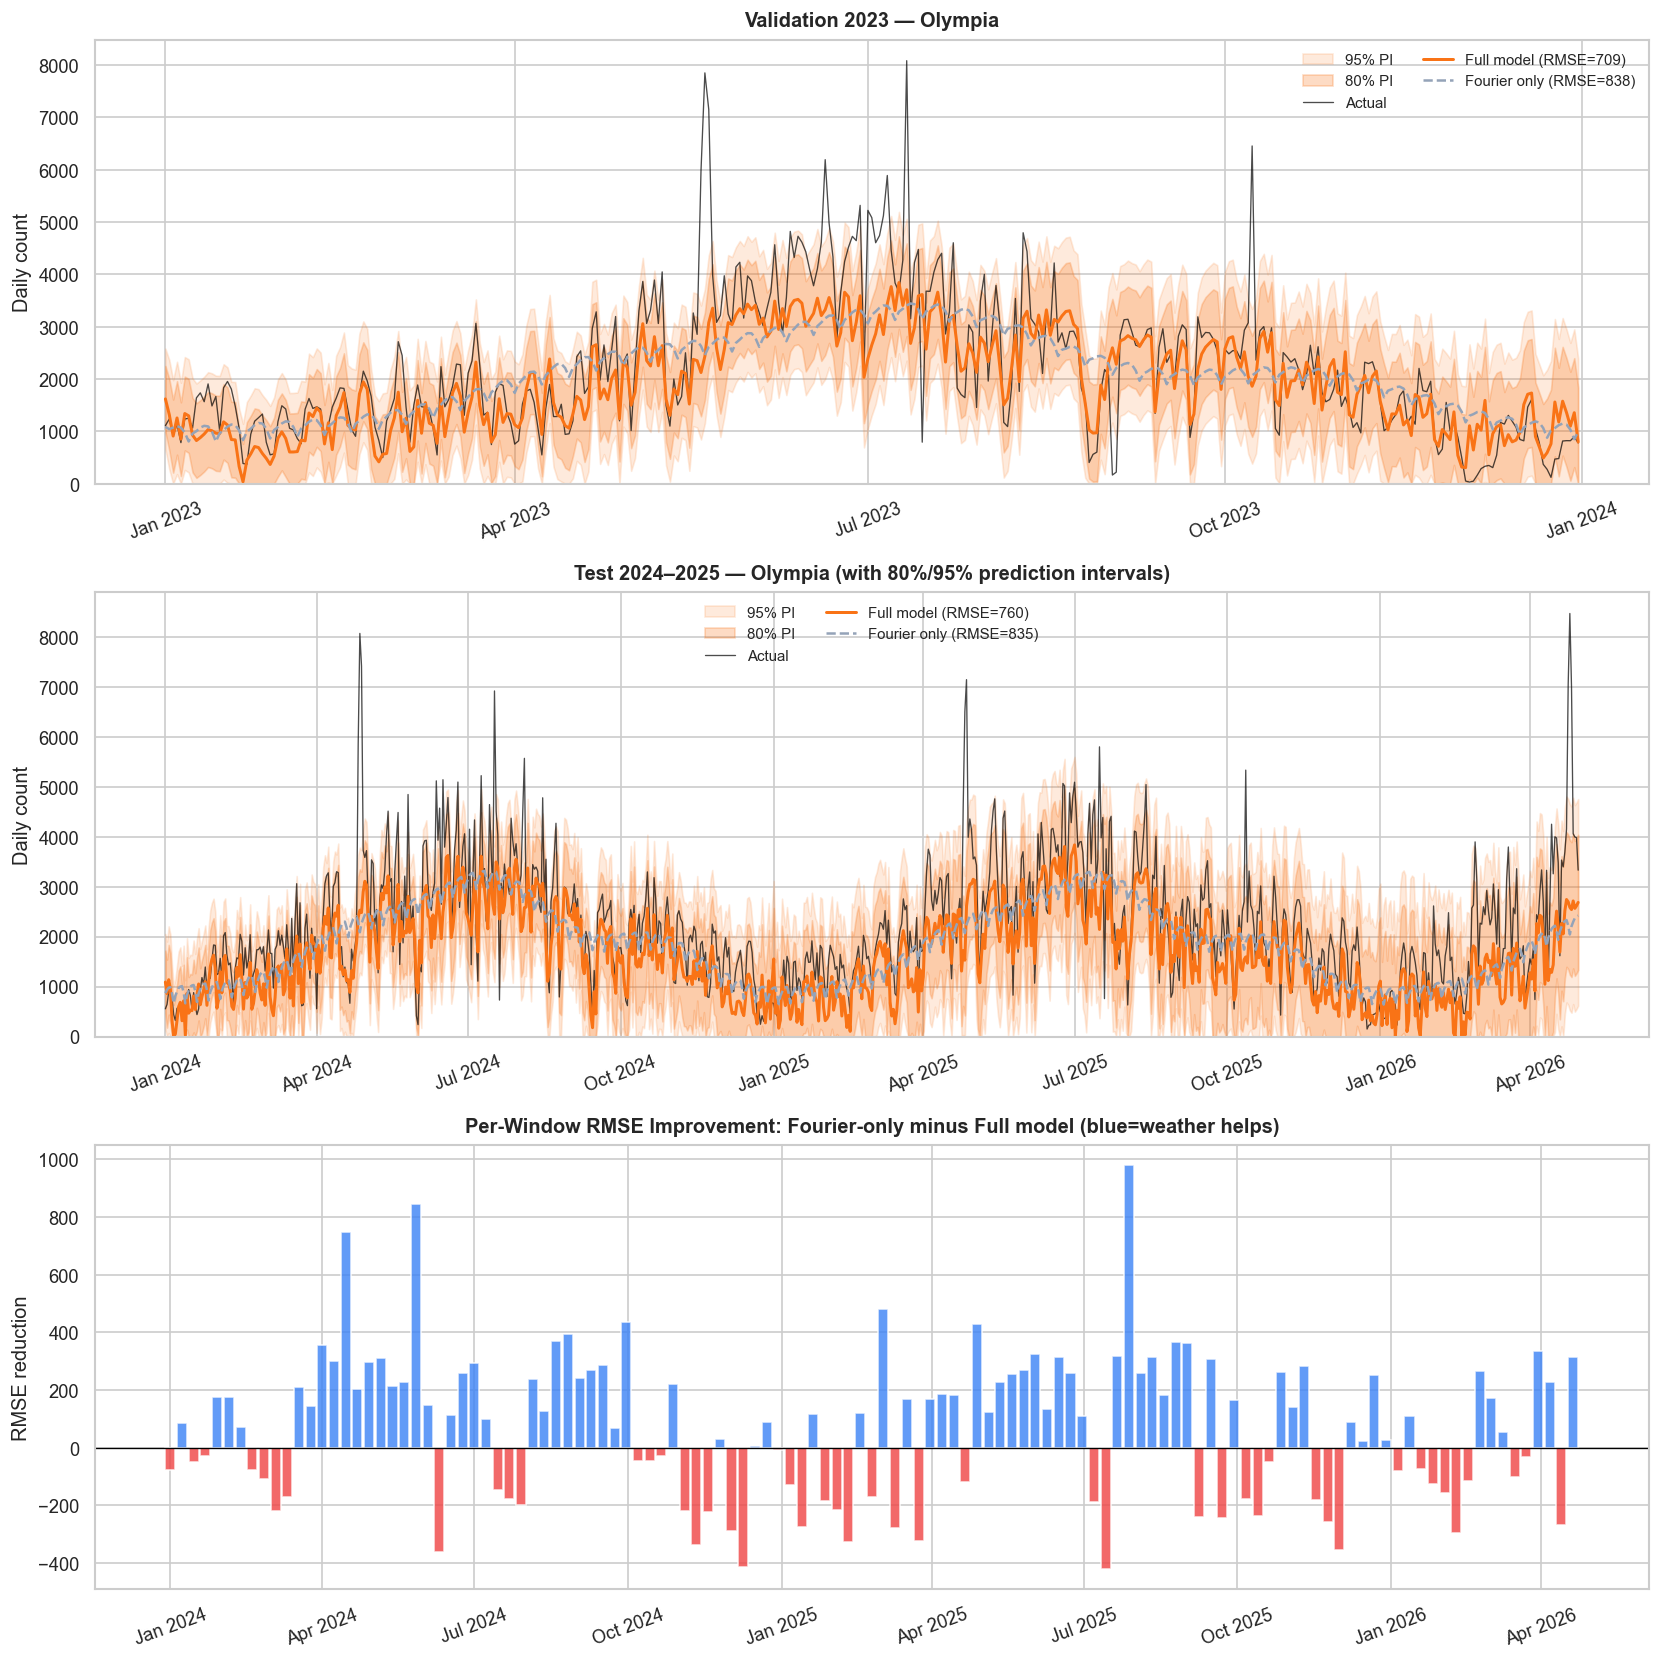

  saved → results/figures/nb06_fig_05_olympia_forecast.png


In [13]:
# ── Get prediction intervals for Olympia full model ─────────────────────
fit_fc = olympia_store['full_model']['fit_tv']
d      = olympia

fourier_test = create_fourier_terms(d['test'].index, OPTIMAL_K)
w_test_df    = d['w_test'][WEATHER_COLS]
ex_test_full = pd.concat([fourier_test, w_test_df], axis=1)

fc = fit_fc.get_forecast(steps=len(d['test']), exog=ex_test_full)
pred_mean = np.maximum(fc.predicted_mean.values, 0)
ci_80     = fc.conf_int(alpha=0.20)
ci_95     = fc.conf_int(alpha=0.05)

fig, axes = plt.subplots(3, 1, figsize=(14, 14))

# Panel 1: Validation
ax = axes[0]
ex_val_f    = create_fourier_terms(d['val'].index, OPTIMAL_K)
ex_val_fw   = pd.concat([ex_val_f, d['w_val'][WEATHER_COLS]], axis=1)

fit_val = olympia_store['full_model']['fit_train']
fc_val  = fit_val.get_forecast(steps=len(d['val']), exog=ex_val_fw)
vp_mean = np.maximum(fc_val.predicted_mean.values, 0)
vp_ci95 = fc_val.conf_int(alpha=0.05)
vp_ci80 = fc_val.conf_int(alpha=0.20)

ax.fill_between(d['val'].index, np.maximum(vp_ci95.iloc[:,0], 0), vp_ci95.iloc[:,1],
                alpha=0.15, color='#f97316', label='95% PI')
ax.fill_between(d['val'].index, np.maximum(vp_ci80.iloc[:,0], 0), vp_ci80.iloc[:,1],
                alpha=0.25, color='#f97316', label='80% PI')
ax.plot(d['val'].index, d['val'].values, color='black', lw=0.8, alpha=0.7, label='Actual')
ax.plot(d['val'].index, vp_mean, color='#f97316', lw=1.8, label=f'Full model (RMSE={evaluate_forecast(d["val"].values, vp_mean, 7)["RMSE"]:.0f})')
ax.plot(d['val'].index, olympia_store['fourier_only']['val_preds'], color='#94a3b8', lw=1.5, ls='--',
        label=f'Fourier only (RMSE={evaluate_forecast(d["val"].values, olympia_store["fourier_only"]["val_preds"], 7)["RMSE"]:.0f})')
ax.set_title('Validation 2023 — Olympia', pad=8)
ax.set_ylabel('Daily count')
ax.legend(fontsize=9, ncol=2)
ax.set_ylim(bottom=0)
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,4,7,10]))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax.get_xticklabels(), rotation=20)

# Panel 2: Test with prediction intervals
ax = axes[1]
ax.fill_between(d['test'].index, np.maximum(ci_95.iloc[:,0], 0), ci_95.iloc[:,1],
                alpha=0.15, color='#f97316', label='95% PI')
ax.fill_between(d['test'].index, np.maximum(ci_80.iloc[:,0], 0), ci_80.iloc[:,1],
                alpha=0.25, color='#f97316', label='80% PI')
ax.plot(d['test'].index, d['test'].values, color='black', lw=0.8, alpha=0.7, label='Actual')
ax.plot(d['test'].index, pred_mean, color='#f97316', lw=1.8,
        label=f'Full model (RMSE={evaluate_forecast(d["test"].values, pred_mean, 7)["RMSE"]:.0f})')
ax.plot(d['test'].index, olympia_store['fourier_only']['test_preds'], color='#94a3b8', lw=1.5, ls='--',
        label=f'Fourier only (RMSE={evaluate_forecast(d["test"].values, olympia_store["fourier_only"]["test_preds"], 7)["RMSE"]:.0f})')
ax.set_title('Test 2024–2025 — Olympia (with 80%/95% prediction intervals)', pad=8)
ax.set_ylabel('Daily count')
ax.legend(fontsize=9, ncol=2)
ax.set_ylim(bottom=0)
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,4,7,10]))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax.get_xticklabels(), rotation=20)

# Panel 3: Per-window improvement (full model vs Fourier-only)
ax = axes[2]
test_vals   = d['test'].values
fou_tp      = olympia_store['fourier_only']['test_preds']
window_dates, improvement_w = [], []
for i in range(0, len(test_vals) - 6, 7):
    yt = test_vals[i:i+7]
    r_fou  = np.sqrt(np.mean((yt - fou_tp[i:i+7])**2))
    r_full = np.sqrt(np.mean((yt - pred_mean[i:i+7])**2))
    window_dates.append(d['test'].index[i])
    improvement_w.append(r_fou - r_full)

impr_arr = np.array(improvement_w)
bar_colors = ['#3b82f6' if v > 0 else '#ef4444' for v in impr_arr]
ax.bar(window_dates, impr_arr, width=6, color=bar_colors, alpha=0.8)
ax.axhline(0, color='black', lw=0.8)
ax.set_title('Per-Window RMSE Improvement: Fourier-only minus Full model (blue=weather helps)', pad=8)
ax.set_ylabel('RMSE reduction')
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,4,7,10]))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax.get_xticklabels(), rotation=20)

plt.tight_layout()
savefig('fig_05_olympia_forecast')

---
## Part 8 — Artefact Export

In [14]:
# ── Save Olympia final model ─────────────────────────────────────────────
with open(MODELS / 'olympia_sarimax_final.pkl', 'wb') as f:
    pickle.dump(olympia_store['full_model']['fit_tv'], f)

# ── Save predictions (all configs) ───────────────────────────────────────
preds_out = pd.DataFrame({
    'date'  : list(olympia['val'].index) + list(olympia['test'].index),
    'actual': list(olympia['val'].values) + list(olympia['test'].values),
    'split' : ['val'] * len(olympia['val']) + ['test'] * len(olympia['test']),
})
for cfg in MODEL_CONFIGS:
    cid = cfg['id']
    preds_out[f'pred_{cid}'] = (
        list(olympia_store[cid]['val_preds']) +
        list(olympia_store[cid]['test_preds'])
    )
preds_out.to_csv(PREDS / 'olympia_sarimax_preds.csv', index=False)

print('Saved:')
print('  results/models/olympia_sarimax_final.pkl')
print('  results/predictions/olympia_sarimax_preds.csv')
print('  results/tables/hirsch_olympia_comparison.csv')
print('  results/tables/coefficient_comparison.csv')
print('  results/figures/nb06_fig_01 through nb06_fig_05')

Saved:
  results/models/olympia_sarimax_final.pkl
  results/predictions/olympia_sarimax_preds.csv
  results/tables/hirsch_olympia_comparison.csv
  results/tables/coefficient_comparison.csv
  results/figures/nb06_fig_01 through nb06_fig_05


---
## Summary

### Findings

| Question | Finding |
|----------|----------|
| Is Olympia more weather-sensitive? | See weather gain (%) comparison |
| Are RMSE levels comparable? | Olympia RMSE reflects recreational noise |
| Coefficient differences significant? | See z-test results (Part 5) |
| Fourier still necessary at Olympia? | Yes — weather-only underperforms Fourier-only |

---
## Thesis figure: temperature–demand scatter with SARIMAX partial coefficients (nb06_fig_06)

OLS regression line for visual fit; SARIMAX partial coefficients annotated.

In [ ]:
# ── nb06_fig_06 — weather sensitivity scatter: Hirsch vs Olympia ─────────────
from scipy.stats import linregress

coef_df = pd.read_csv(TABLES / 'coefficient_comparison.csv')
sarimax_coef = {
    row['Variable']: {'Hirsch': row['Hirsch_coef'], 'Olympia': row['Olympia_coef']}
    for _, row in coef_df.iterrows()
}

df_all = df_full.copy()
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
st_colors = {'Hirsch': '#2ca02c', 'Olympia': '#17becf'}

for ax, st in zip(axes, ['Hirsch', 'Olympia']):
    sdf = (df_all[(df_all['station'] == st) &
                  (df_all['date'] >= TRAIN_START) &
                  (df_all['date'] <= TRAIN_END)]
           .dropna(subset=['total', 'max_temp']))
    x, y   = sdf['max_temp'].values, sdf['total'].values
    slope, intercept, r, *_ = linregress(x, y)
    coef = sarimax_coef['max_temp'][st]

    ax.scatter(x, y, s=4, alpha=0.2, color=st_colors[st], zorder=2)
    xfit = np.linspace(x.min(), x.max(), 100)
    ax.plot(xfit, slope * xfit + intercept, lw=2.2, color='#333', zorder=4)
    ax.text(0.04, 0.95,
            f'SARIMAX partial coef = {coef:.1f} counts/°C\n(OLS slope = {slope:.1f})',
            transform=ax.transAxes, fontsize=9, va='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85))
    ax.set_xlabel('Max Temperature (°C)')
    ax.set_ylabel('Daily count' if st == 'Hirsch' else '')
    ax.set_title(st)

fig.suptitle(
    'Temperature vs Cyclist Count — Training 2013–2022\n'
    'Lines show OLS fit; annotated coefficients are partial estimates from the full '
    'SARIMAX weather specification controlling for all three regressors.',
    fontsize=9.5)
fig.tight_layout()
savefig('fig_06_weather_sensitivity_scatter')
